In [40]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated")

In [1]:
import os
import pandas as pd 
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent   # notebooks/ -> project root
sys.path.append(str(PROJECT_ROOT))

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
filtered_df = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/filtered/filtered_final.parquet"))
importance_df = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/filtered/filtered_importance.parquet"))

In [21]:
filtered_df[filtered_df["TransactionAmt"] > 10000]["TransactionAmt"]

274336    31937.390625
274339    31937.390625
Name: TransactionAmt, dtype: float32

In [27]:
filtered_df.shape

(590540, 74)

In [31]:
importance_df[importance_df["Feature"] == "TransactionAmt"]

,Feature,Importance
30,TransactionAmt,0.004104


## Summary Stats

In [10]:
filtered_df.head()

,V258,V189,V70,id_12,C12,V207,V219,V54,V72,V227,...,V67,V222,V77,V7,V246,D8,V55,id_04,id_11,isFraud
0,NaN,NaN,0.0,None,0.0,NaN,NaN,1.0,0.0,NaN,...,1.0,NaN,1.0,1.0,NaN,NaN,1.0,NaN,NaN,0
1,NaN,NaN,0.0,None,0.0,NaN,NaN,0.0,0.0,NaN,...,1.0,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,0
2,NaN,NaN,0.0,None,0.0,NaN,NaN,1.0,0.0,NaN,...,1.0,NaN,1.0,1.0,NaN,NaN,1.0,NaN,NaN,0
3,NaN,NaN,0.0,None,0.0,NaN,NaN,1.0,0.0,NaN,...,1.0,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,0
4,1.0,1.0,NaN,NotFound,0.0,0.0,0.0,NaN,NaN,0.0,...,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,100.0,0


In [4]:
print(f"There are {filtered_df.shape[1]} features and {filtered_df.shape[0]} observations")

There are 73 features and 590540 observations


In [5]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 73 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   V258            130430 non-null  float32
 1   V189            139819 non-null  float32
 2   V70             513444 non-null  float32
 3   id_12           144233 non-null  object 
 4   C12             590540 non-null  float32
 5   V207            139631 non-null  float32
 6   V219            130430 non-null  float32
 7   V54             513444 non-null  float32
 8   V72             513444 non-null  float32
 9   V227            141416 non-null  float32
 10  V194            139819 non-null  float32
 11  V29             514467 non-null  float32
 12  C13             590540 non-null  float32
 13  V224            130430 non-null  float32
 14  V33             514467 non-null  float32
 15  D3              327662 non-null  float32
 16  V62             513444 non-null  float32
 17  M4        

In [6]:
columns = filtered_df.columns.drop("isFraud")
columns_categories_dict = {
    "D": [],
    "V": [],
    "id": [],
    "M": [],
    "others": []
}

for column in columns:
    if column.startswith("D"):
        if column == "DeviceInfo":
            columns_categories_dict["others"].append(column)
        else:
            columns_categories_dict["D"].append(column)
    elif column.startswith("V"):
        columns_categories_dict["V"].append(column)
    elif column.startswith("id"):
        columns_categories_dict["id"].append(column)
    elif column.startswith("M"):
        columns_categories_dict["M"].append(column)
    else:
        columns_categories_dict["others"].append(column)

category_df = df = pd.DataFrame({
    "Category type": columns_categories_dict.keys(),
    "Category List": columns_categories_dict.values(),
    "Number of features": [len(v) for v in columns_categories_dict.values()]
}).sort_values(by="Number of features", ascending=False)
    

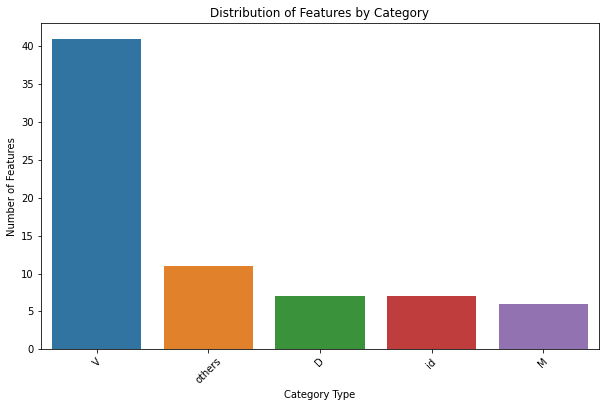

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Category type", y="Number of features", data=category_df)
plt.title("Distribution of Features by Category")
plt.xlabel("Category Type")
plt.ylabel("Number of Features")
plt.xticks(rotation=45)
plt.show()

In [8]:
df

,Category type,Category List,Number of features
1,V,"[V258, V189, V70, V207, V219, V54, V72, V227, ...",41
4,others,"[C12, C13, DeviceInfo, TransactionDT, R_emaild...",11
0,D,"[D3, D2, D13, D15, D12, D10, D8]",7
2,id,"[id_12, id_03, id_09, id_31, id_17, id_04, id_11]",7
3,M,"[M4, M9, M2, M3, M8, M6]",6


In [52]:
category_df

,Category type,Category List,Number of features
0,D,"[D3, D2, D7, D8, D15, D12, D11, D10, D13]",9
1,V,"[V258, V225, V189, V207, V91, V219, V198, V22,...",50
2,id,"[id_04, id_03, id_38, id_17, id_09, id_31, id_...",11
3,M,"[M2, M4, M3, M6, M9]",5
4,others,"[DeviceInfo, R_emaildomain, addr1, dist1, addr2]",5


In [20]:
cleaned_df["V258"].value_counts()

V258
1.0     112953
2.0      11247
3.0       2696
4.0       1062
5.0        569
         ...  
50.0         1
41.0         1
42.0         1
43.0         1
52.0         1
Name: count, Length: 67, dtype: int64

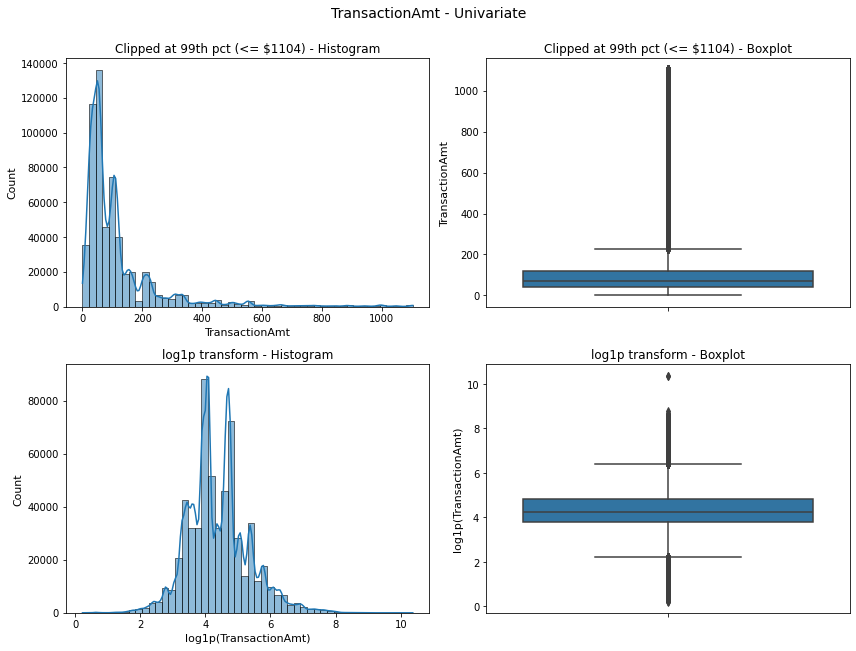

In [24]:
p99 = filtered_df["TransactionAmt"].quantile(0.99)
filtered_df["log_amt"] = np.log1p(filtered_df["TransactionAmt"])
clipped_df = filtered_df[filtered_df["TransactionAmt"] <= p99]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.histplot(data=clipped_df, x="TransactionAmt", bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title(f"Clipped at 99th pct (<= ${p99:.0f}) - Histogram", fontsize=12)
axes[0,0].set_xlabel("TransactionAmt", fontsize=11)
axes[0,0].set_ylabel("Count", fontsize=11)

sns.boxplot(data=clipped_df, y="TransactionAmt", ax=axes[0,1])
axes[0,1].set_title(f"Clipped at 99th pct (<= ${p99:.0f}) - Boxplot", fontsize=12)
axes[0,1].set_ylabel("TransactionAmt", fontsize=11)

sns.histplot(data=filtered_df, x="log_amt", bins=50, kde=True, ax=axes[1,0])
axes[1,0].set_title("log1p transform - Histogram", fontsize=12)
axes[1,0].set_xlabel("log1p(TransactionAmt)", fontsize=11)
axes[1,0].set_ylabel("Count", fontsize=11)

sns.boxplot(data=filtered_df, y="log_amt", ax=axes[1,1])
axes[1,1].set_title("log1p transform - Boxplot", fontsize=12)
axes[1,1].set_ylabel("log1p(TransactionAmt)", fontsize=11)

plt.suptitle("TransactionAmt - Univariate", y=1.00, fontsize=14)
plt.tight_layout()

### Transaction DT

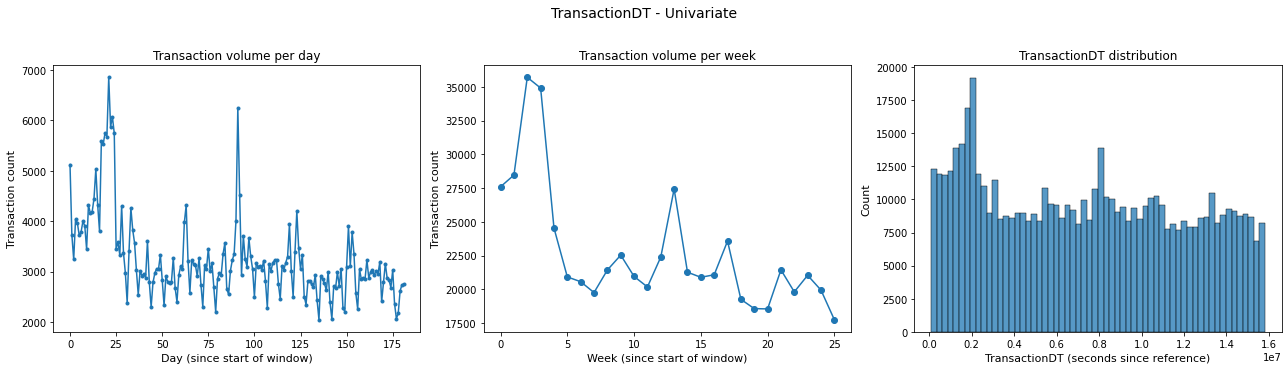

In [52]:
day = (filtered_df["TransactionDT"] - filtered_df["TransactionDT"].min()) // (60*60*24)
week = day // 7

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

daily_counts = filtered_df.groupby(day).size()
axes[0].plot(daily_counts.index, daily_counts.values, marker="o", markersize=3)
axes[0].set_title("Transaction volume per day", fontsize=12)
axes[0].set_xlabel("Day (since start of window)", fontsize=11)
axes[0].set_ylabel("Transaction count", fontsize=11)

weekly_counts = filtered_df.groupby(week).size()
axes[1].plot(weekly_counts.index, weekly_counts.values, marker="o")
axes[1].set_title("Transaction volume per week", fontsize=12)
axes[1].set_xlabel("Week (since start of window)", fontsize=11)
axes[1].set_ylabel("Transaction count", fontsize=11)

sns.histplot(data=filtered_df, x="TransactionDT", bins=60, ax=axes[2])
axes[2].set_title("TransactionDT distribution", fontsize=12)
axes[2].set_xlabel("TransactionDT (seconds since reference)", fontsize=11)
axes[2].set_ylabel("Count", fontsize=11)

plt.suptitle("TransactionDT - Univariate", y=1.02, fontsize=14)
plt.tight_layout()

### V categories

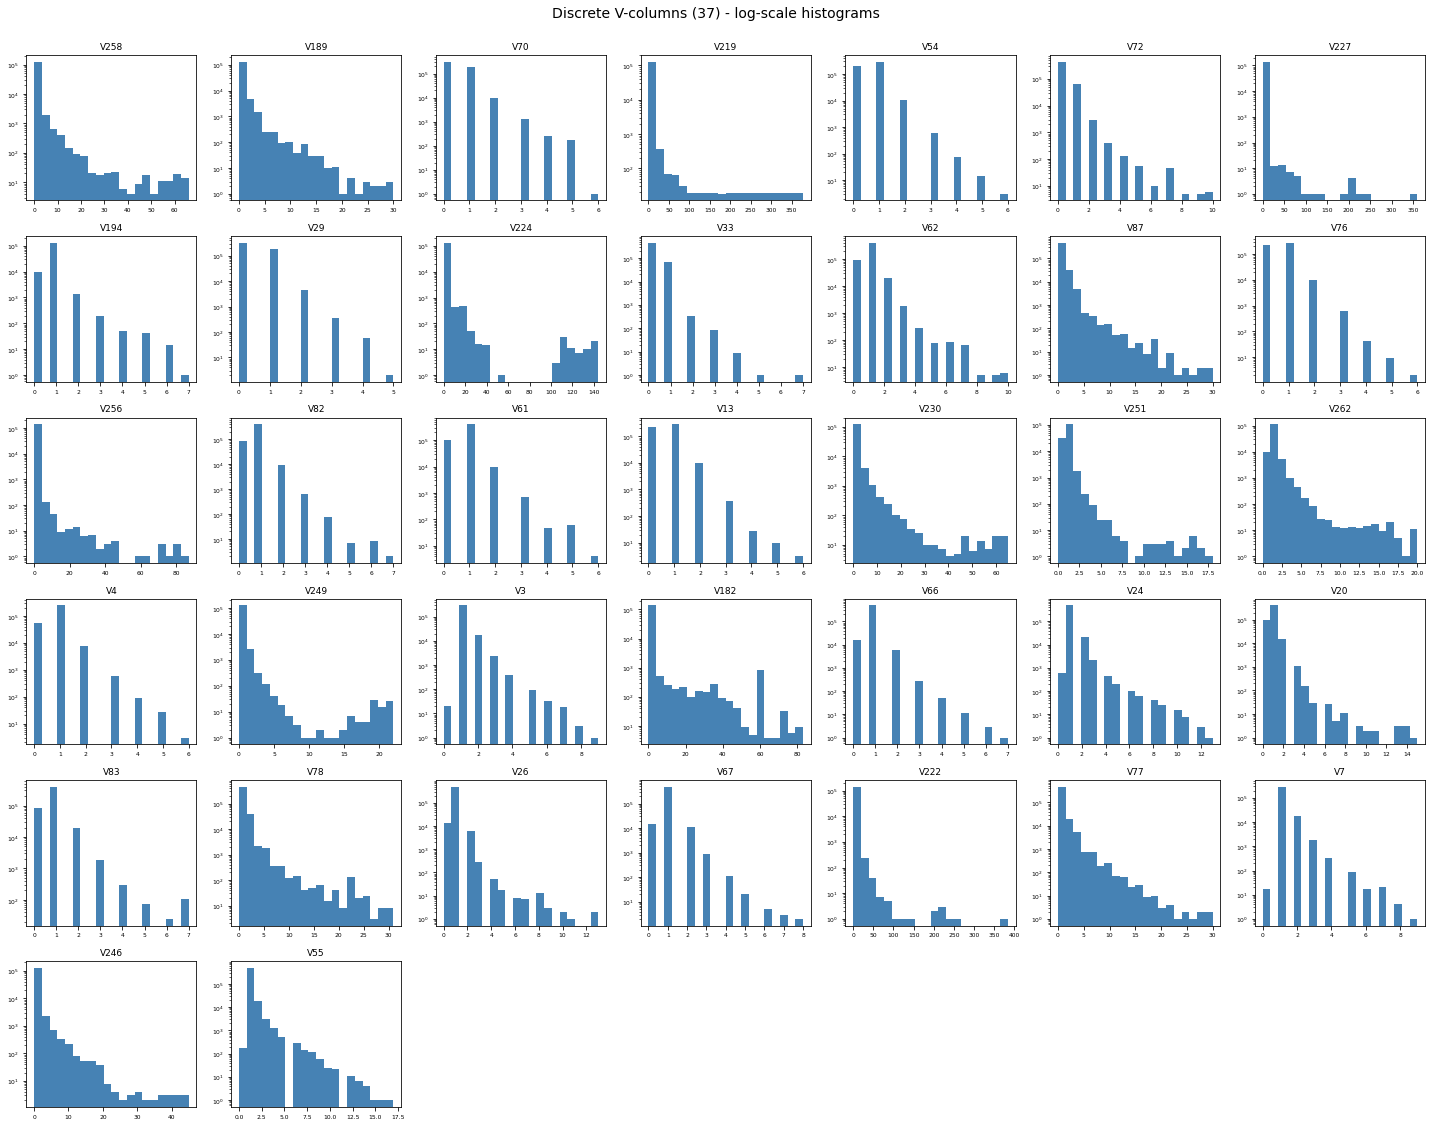

In [49]:
v_cols_all = [c for c in filtered_df.columns if c.startswith("V")]
continuous_v = ["V207", "V209", "V210", "V268"]
discrete_v = [c for c in v_cols_all if c not in continuous_v]

# 1. Discrete V-columns (37) - compact scan grid
n_cols = 7
n_rows = -(-len(discrete_v) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2.6 * n_rows))
axes = axes.ravel()

for i, col in enumerate(discrete_v):
    axes[i].hist(filtered_df[col].dropna(), bins=20, color="steelblue")
    axes[i].set_yscale("log")
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Discrete V-columns (37) - log-scale histograms", y=1.00, fontsize=14)
plt.tight_layout()

In [50]:
continuous_v = ["V207", "V209", "V210", "V268"]

# 1. Zero-rate summary (report as a stat, not a plot)
zero_rates = {}
for col in continuous_v:
    vals = filtered_df[col].dropna()
    zero_rates[col] = (vals == 0).mean() * 100

zero_rate_df = pd.DataFrame.from_dict(zero_rates, orient="index", columns=["pct_zero"]).round(1)
print(zero_rate_df)

      pct_zero
V207      88.2
V209      87.8
V210      88.4
V268      89.2


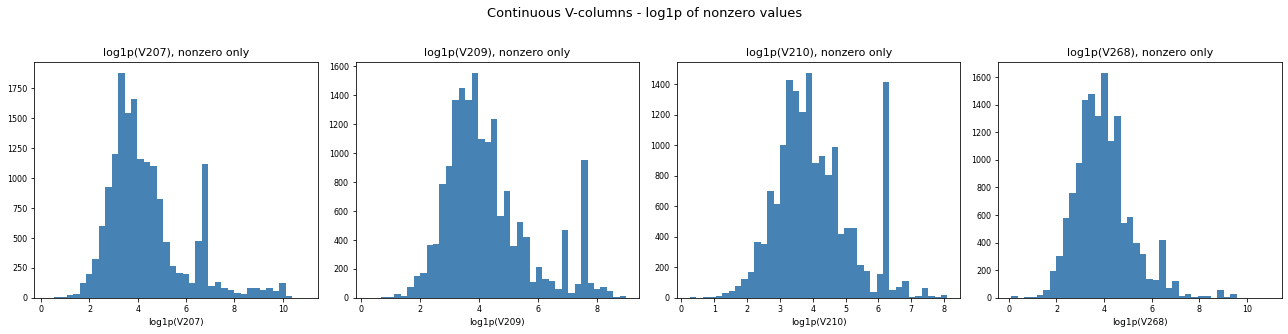

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for i, col in enumerate(continuous_v):
    nz = filtered_df[col].dropna()
    nz = nz[nz > 0]
    log_nz = np.log1p(nz)
    axes[i].hist(log_nz, bins=40, color="steelblue")
    axes[i].set_title(f"log1p({col}), nonzero only", fontsize=11)
    axes[i].set_xlabel(f"log1p({col})", fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.suptitle("Continuous V-columns - log1p of nonzero values", y=1.02, fontsize=13)
plt.tight_layout()

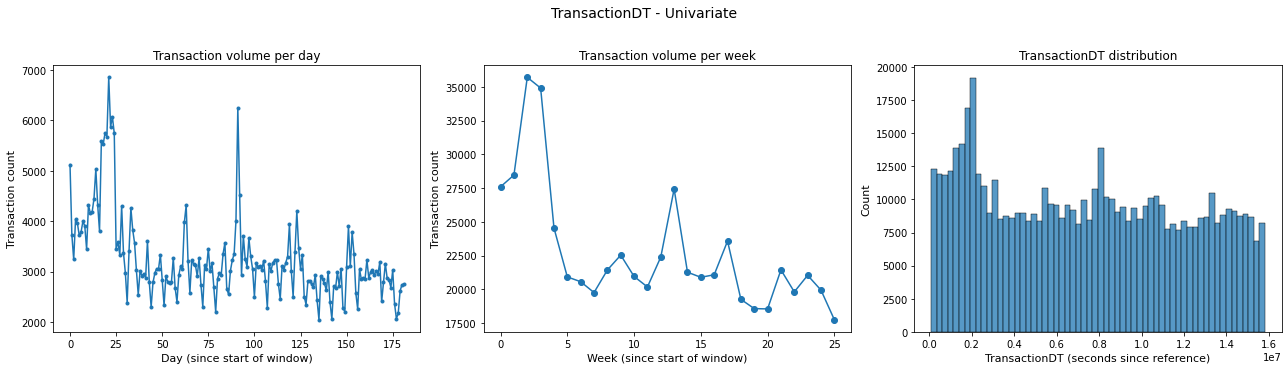

In [34]:
day = (filtered_df["TransactionDT"] - filtered_df["TransactionDT"].min()) // (60*60*24)
week = day // 7

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

daily_counts = filtered_df.groupby(day).size()
axes[0].plot(daily_counts.index, daily_counts.values, marker="o", markersize=3)
axes[0].set_title("Transaction volume per day", fontsize=12)
axes[0].set_xlabel("Day (since start of window)", fontsize=11)
axes[0].set_ylabel("Transaction count", fontsize=11)

weekly_counts = filtered_df.groupby(week).size()
axes[1].plot(weekly_counts.index, weekly_counts.values, marker="o")
axes[1].set_title("Transaction volume per week", fontsize=12)
axes[1].set_xlabel("Week (since start of window)", fontsize=11)
axes[1].set_ylabel("Transaction count", fontsize=11)

sns.histplot(data=filtered_df, x="TransactionDT", bins=60, ax=axes[2])
axes[2].set_title("TransactionDT distribution", fontsize=12)
axes[2].set_xlabel("TransactionDT (seconds since reference)", fontsize=11)
axes[2].set_ylabel("Count", fontsize=11)

plt.suptitle("TransactionDT - Univariate", y=1.02, fontsize=14)
plt.tight_layout()

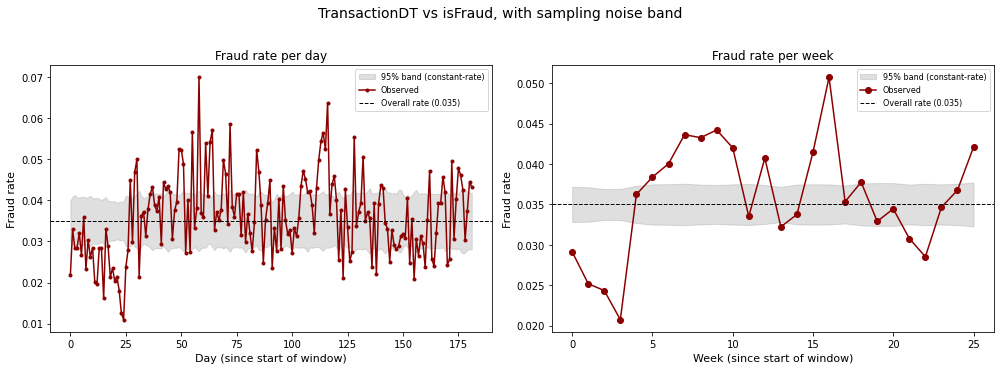

In [36]:
p = filtered_df["isFraud"].mean()

day = (filtered_df["TransactionDT"] - filtered_df["TransactionDT"].min()) // (60*60*24)
week = day // 7

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

daily = filtered_df.groupby(day)["isFraud"].agg(["mean", "size"])
daily["se"] = np.sqrt(p * (1 - p) / daily["size"])
daily["upper"] = p + 1.96 * daily["se"]
daily["lower"] = (p - 1.96 * daily["se"]).clip(lower=0)

axes[0].fill_between(daily.index, daily["lower"], daily["upper"], color="gray", alpha=0.25, label="95% band (constant-rate)")
axes[0].plot(daily.index, daily["mean"], marker="o", markersize=3, color="darkred", label="Observed")
axes[0].axhline(p, color="black", linestyle="--", linewidth=1, label=f"Overall rate ({p:.3f})")
axes[0].set_title("Fraud rate per day", fontsize=12)
axes[0].set_xlabel("Day (since start of window)", fontsize=11)
axes[0].set_ylabel("Fraud rate", fontsize=11)
axes[0].legend(fontsize=8)

weekly = filtered_df.groupby(week)["isFraud"].agg(["mean", "size"])
weekly["se"] = np.sqrt(p * (1 - p) / weekly["size"])
weekly["upper"] = p + 1.96 * weekly["se"]
weekly["lower"] = (p - 1.96 * weekly["se"]).clip(lower=0)

axes[1].fill_between(weekly.index, weekly["lower"], weekly["upper"], color="gray", alpha=0.25, label="95% band (constant-rate)")
axes[1].plot(weekly.index, weekly["mean"], marker="o", color="darkred", label="Observed")
axes[1].axhline(p, color="black", linestyle="--", linewidth=1, label=f"Overall rate ({p:.3f})")
axes[1].set_title("Fraud rate per week", fontsize=12)
axes[1].set_xlabel("Week (since start of window)", fontsize=11)
axes[1].set_ylabel("Fraud rate", fontsize=11)
axes[1].legend(fontsize=8)

plt.suptitle("TransactionDT vs isFraud, with sampling noise band", y=1.02, fontsize=14)
plt.tight_layout()

In [17]:
cleaned_df["V91"].value_counts()

V91
0.0    305135
1.0    184121
2.0     10470
3.0      1086
4.0       336
5.0       222
6.0         6
Name: count, dtype: int64

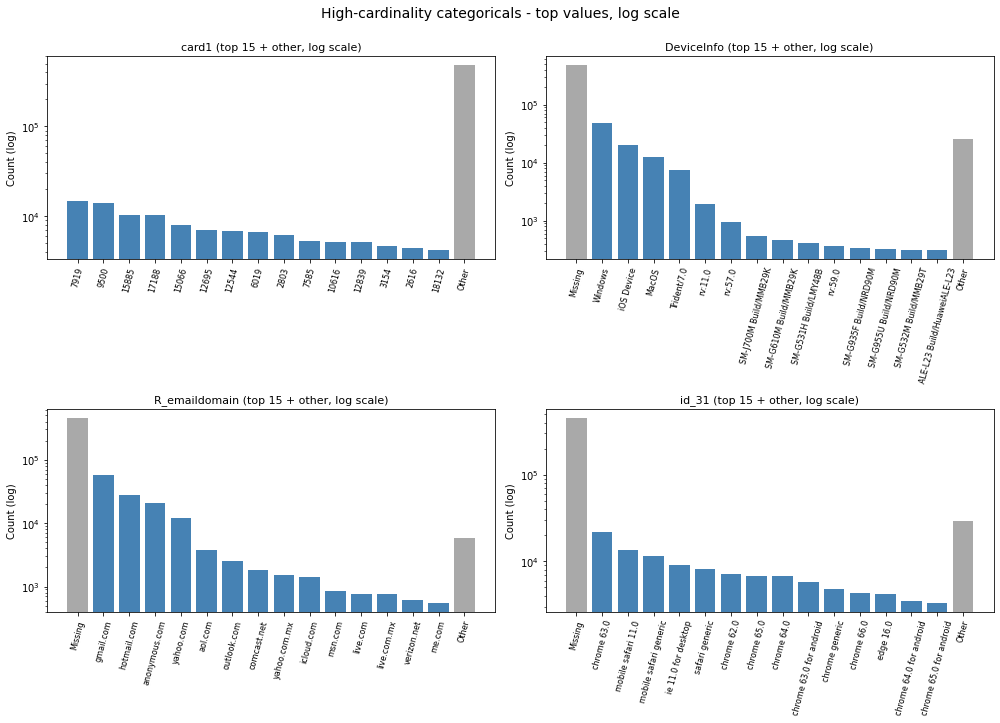

In [47]:
high_card_cols = ["card1", "DeviceInfo", "R_emaildomain", "id_31"]
top_n = 15

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(high_card_cols):
    filled = filtered_df[col].fillna("Missing").astype(str)
    counts = filled.value_counts()
    top = counts.head(top_n)
    other_count = counts.iloc[top_n:].sum()
    if other_count > 0:
        top = pd.concat([top, pd.Series({"Other": other_count})])
    colors = ["darkgray" if lab in ("Missing", "Other") else "steelblue" for lab in top.index]
    axes[i].bar(top.index.astype(str), top.values, color=colors)
    axes[i].set_yscale("log")
    axes[i].set_title(f"{col} (top {top_n} + other, log scale)", fontsize=11)
    axes[i].set_ylabel("Count (log)", fontsize=10)
    axes[i].tick_params(axis="x", rotation=75, labelsize=8)

plt.suptitle("High-cardinality categoricals - top values, log scale", y=1.00, fontsize=14)
plt.tight_layout()

In [46]:
filtered_df["addr1"].value_counts()

addr1
299.0    46335
325.0    42751
204.0    42020
264.0    39870
330.0    26287
         ...  
386.0        1
101.0        1
353.0        1
516.0        1
245.0        1
Name: count, Length: 332, dtype: int64

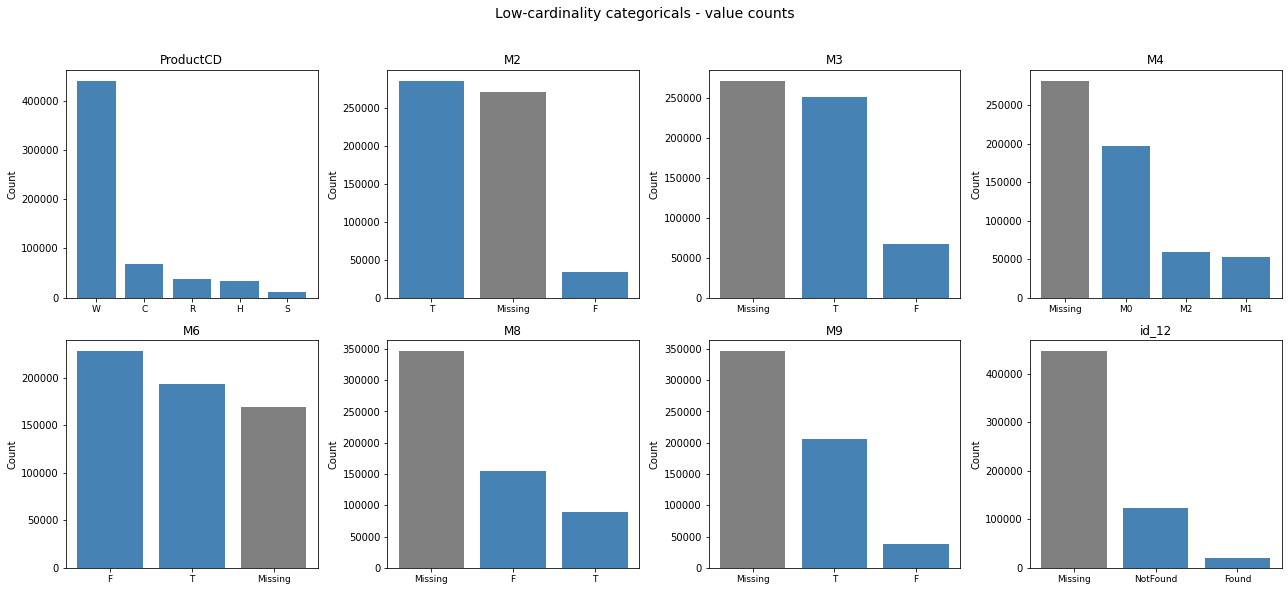

In [37]:
cat_cols = ["ProductCD", "M2", "M3", "M4", "M6", "M8", "M9", "id_12"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    counts = filtered_df[col].value_counts(dropna=False)
    labels = [str(x) if pd.notna(x) else "Missing" for x in counts.index]
    colors = ["gray" if lab == "Missing" else "steelblue" for lab in labels]
    axes[i].bar(labels, counts.values, color=colors)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel("Count", fontsize=10)
    axes[i].tick_params(axis="x", labelsize=9)

plt.suptitle("Low-cardinality categoricals - value counts", y=1.02, fontsize=14)
plt.tight_layout()

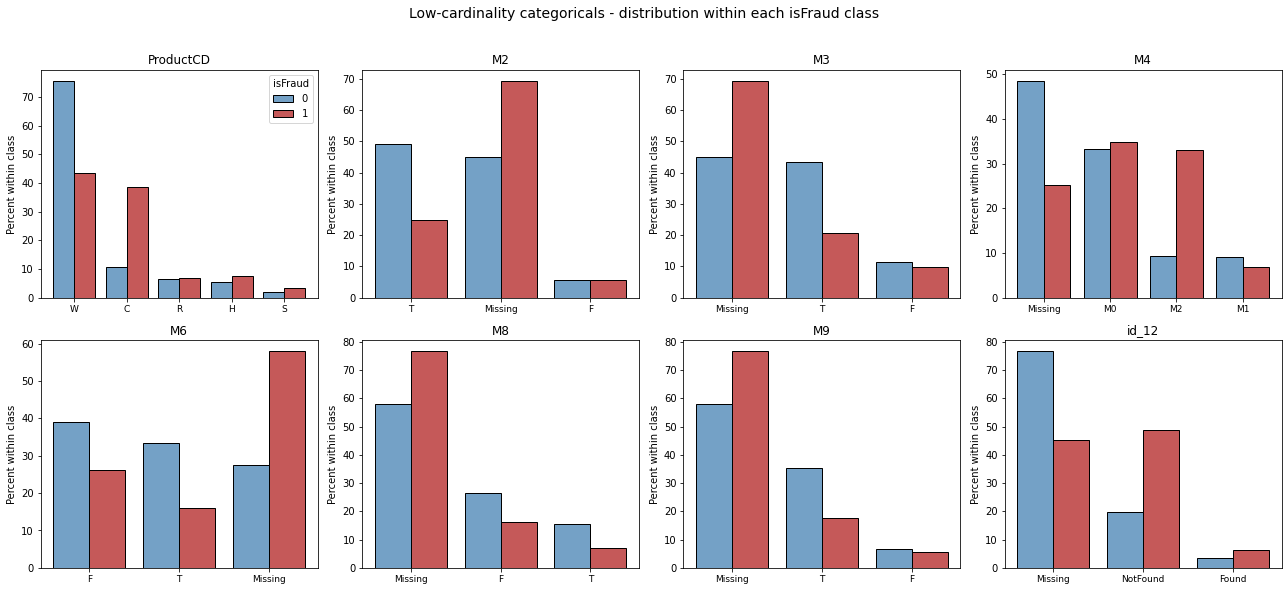

In [41]:
cat_cols = ["ProductCD", "M2", "M3", "M4", "M6", "M8", "M9", "id_12"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    plot_df = filtered_df[[col, "isFraud"]].copy()
    plot_df[col] = plot_df[col].fillna("Missing")
    order = plot_df[col].value_counts().index.tolist()
    plot_df[col] = pd.Categorical(plot_df[col], categories=order, ordered=True)
    sns.histplot(data=plot_df, x=col, hue="isFraud", multiple="dodge", stat="percent",
                 common_norm=False, shrink=0.8, ax=axes[i],
                 palette=["steelblue", "firebrick"], legend=(i == 0))
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel("Percent within class", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", labelsize=9)

plt.suptitle("Low-cardinality categoricals - distribution within each isFraud class", y=1.02, fontsize=14)
plt.tight_layout()

In [42]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(col, target):
    filled = col.fillna("Missing")
    table = pd.crosstab(filled, target)
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.sum().sum()
    k = min(table.shape) - 1
    v = np.sqrt(chi2 / (n * k))
    return chi2, p, v

cat_cols = ["ProductCD", "M2", "M3", "M4", "M6", "M8", "M9", "id_12"]

results = []
for c in cat_cols:
    chi2, p, v = cramers_v(filtered_df[c], filtered_df["isFraud"])
    results.append({"feature": c, "chi2": round(chi2, 1), "p_value": p, "cramers_v": round(v, 4)})

results_df = pd.DataFrame(results).sort_values("cramers_v", ascending=False).reset_index(drop=True)
results_df

,feature,chi2,p_value,cramers_v
0,ProductCD,16742.2,0.0,0.1684
1,M4,13356.2,0.0,0.1504
2,id_12,10941.0,0.0,0.1361
3,M6,9096.5,0.0,0.1241
4,M3,4997.2,0.0,0.0920
5,M2,4974.8,0.0,0.0918
6,M9,3021.4,0.0,0.0715
7,M8,2928.5,0.0,0.0704


**Overall summary — categorical features vs `isFraud`**

All eight low-cardinality categoricals (`ProductCD`, `M2`, `M3`, `M4`, `M6`, `M8`, `M9`, `id_12`) show a statistically significant association with `isFraud` (chi-square, p < .001), though at this sample size significance alone is uninformative — Cramér's V is used to rank actual strength, ranging from 0.168 (`ProductCD`) down to 0.070 (`M8`).

The more useful finding is *why* each feature is associated with fraud, which splits into three distinct patterns rather than one uniform story:

- **Missingness-driven** (`M2`, `M3`, `M6`, `M8`, `M9`) — populated values differ only modestly; the "Missing" category itself carries 2-4x the baseline fraud rate. Covers 5 of 8 features and matches the same informative-missingness pattern already found in the numeric `D`- and `V`-columns.
- **Real category effect** (`ProductCD`, `M4`) — specific populated values, not absence, carry the risk (`ProductCD=C` at 11.7% vs `ProductCD=W` at 2.0%).
- **Inverted pattern** (`id_12`) — the exception: `Missing` is the *safest* bucket (2.1%), while a populated-but-failed check (`NotFound`, 8.2%) is riskiest.

**Takeaway:** missingness is not noise to be imputed away in this dataset — for the majority of categorical features it is the primary signal, not a secondary one. It should be preserved as an explicit category (or left as native NaN for XGBoost's categorical split handling) rather than filled, with `id_12` flagged as the one feature where the usual "missing = risk" direction reverses and warrants individual attention during feature engineering.

In [4]:
importance_df

,Feature,Importance
0,V258,0.172134
1,V225,0.120912
2,V189,0.049160
3,V207,0.027222
4,V91,0.026194
...,...,...
75,V11,0.001891
76,D10,0.001874
77,V262,0.001804
78,id_11,0.001783


In [19]:
top12_importance = importance_df.loc[:12, "Feature"].tolist()

In [25]:
cleaned_df['V219'].isna().mean()



0.7791343516103905

In [26]:
cleaned_df['V219'].describe()

count    130430.000000
mean          1.367132
std          12.044032
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         378.000000
Name: V219, dtype: float64

In [23]:
cleaned_df['V219'].isna().mean()
cleaned_df['V219'].describe()
cleaned_df['V219'].value_counts().head(10)

V219
0.0    94337
1.0    16438
2.0     7419
3.0     4045
4.0     2435
5.0     1393
6.0      924
7.0      633
8.0      468
9.0      347
Name: count, dtype: int64

c:\Users\Gordon Li\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Gordon Li\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Gordon Li\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Gordon Li\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:111

IndexError: index 12 is out of bounds for axis 0 with size 12

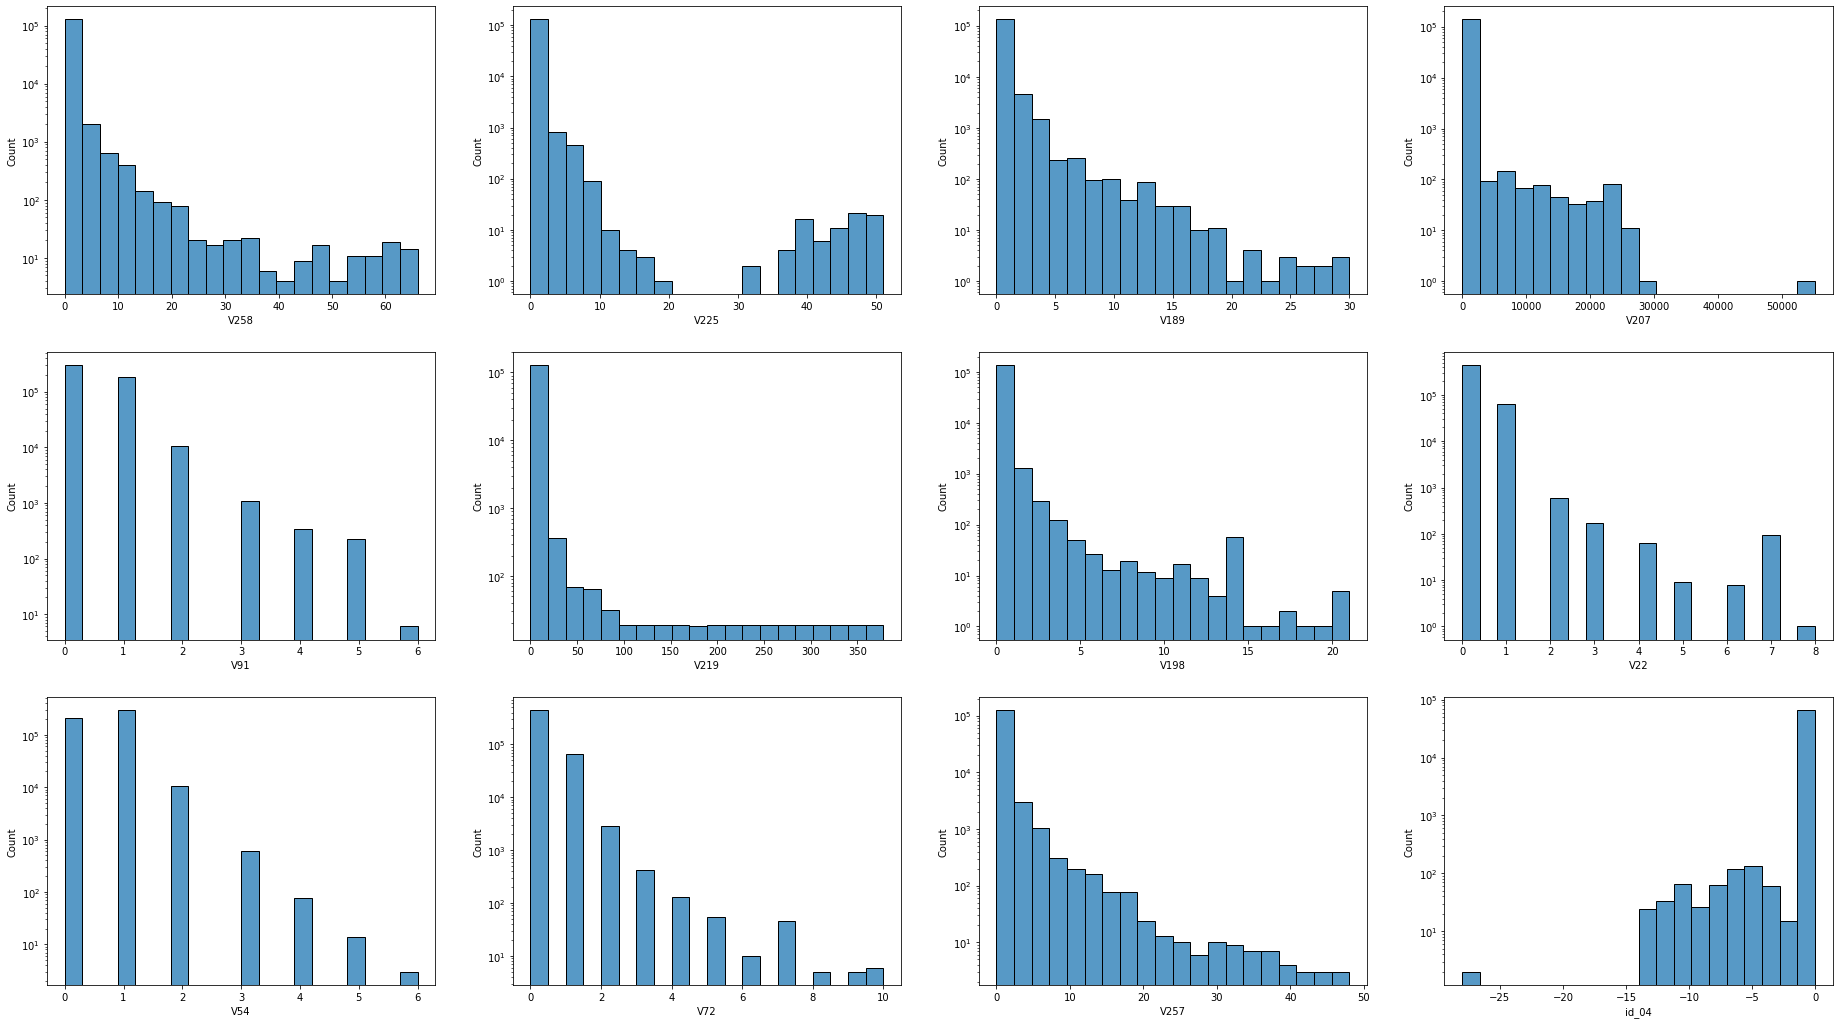

In [24]:
fig, axs = plt.subplots(3, 4, figsize=(32, 18))
axs = axs.ravel() 
for i, feature in enumerate(top12_importance):
    sns.histplot(cleaned_df[feature], ax=axs[i], bins=20, log_scale=(False, True))

In [40]:
cleaned_df.shape

(590540, 81)

In [30]:
cleaned_df.isnull().sum().sort_values()

isFraud         0
addr2       65706
addr1       65706
D10         76022
V13         76073
            ...  
id_04      524216
id_03      524216
D12        525823
D13        528588
D7         551623
Length: 81, dtype: int64

In [36]:
cleaned_df["addr1"].value_counts()

addr1
299.0    46335
325.0    42751
204.0    42020
264.0    39870
330.0    26287
         ...  
386.0        1
101.0        1
353.0        1
516.0        1
245.0        1
Name: count, Length: 332, dtype: int64

In [39]:
cleaned_df["addr2"].value_counts()

addr2
87.0    520481
60.0      3084
96.0       638
32.0        91
65.0        82
         ...  
49.0         1
14.0         1
25.0         1
22.0         1
93.0         1
Name: count, Length: 74, dtype: int64

In [33]:
cleaned_df.columns

Index(['V258', 'V225', 'V189', 'V207', 'V91', 'V219', 'V198', 'V22', 'V54',
       'V72', 'V257', 'id_04', 'V188', 'V248', 'D3', 'V94', 'V271', 'V243',
       'M2', 'V200', 'V29', 'V256', 'V227', 'DeviceInfo', 'V199', 'V87',
       'V261', 'V76', 'R_emaildomain', 'V62', 'V180', 'V67', 'M4', 'V205',
       'M3', 'V209', 'id_03', 'D2', 'V251', 'V169', 'V82', 'V56', 'V13', 'D7',
       'id_38', 'V23', 'V216', 'V83', 'id_17', 'id_09', 'V181', 'M6', 'V26',
       'V3', 'addr1', 'V220', 'V192', 'D8', 'id_31', 'id_12', 'V5', 'id_20',
       'V226', 'V20', 'M9', 'D15', 'id_06', 'dist1', 'V170', 'D12', 'V59',
       'addr2', 'D11', 'id_15', 'V61', 'V11', 'D10', 'V262', 'id_11', 'D13',
       'isFraud'],
      dtype='object')

In [32]:
cleaned_df["id_03"].value_counts()

id_03
 0.0     63903
 1.0       863
 3.0       668
 2.0       421
 5.0       109
 4.0       100
 6.0        64
-5.0        33
-6.0        31
-7.0        21
-4.0        21
-10.0       17
-8.0        14
-1.0        12
-2.0        12
-3.0         8
-11.0        6
-9.0         6
 7.0         4
 9.0         3
-12.0        3
-13.0        3
 10.0        1
 8.0         1
Name: count, dtype: int64

In [21]:
cleaned_df["V207"].value_counts()

V207
0.000000      123086
877.000000       914
50.000000        552
100.000000       483
619.000000       342
               ...  
57.104301          1
138.845200         1
65.857803          1
30.665800          1
6.271000           1
Name: count, Length: 3246, dtype: int64

In [7]:
cleaned_df["V258"].value_counts()

V258
1.0     112953
2.0      11247
3.0       2696
4.0       1062
5.0        569
         ...  
50.0         1
41.0         1
42.0         1
43.0         1
52.0         1
Name: count, Length: 67, dtype: int64

In [5]:
train["importance_df"]

NameError: name 'train' is not defined

In [7]:
len(cleaned_df.columns)

81

In [ ]:
df["V25"]

<Axes: xlabel='isFraud', ylabel='count'>

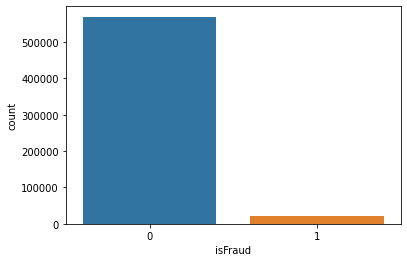

In [12]:
sns.countplot(data=df, x="isFraud")

In [7]:
df.isnull().sum()

V258       460110
V225       460110
V189       450721
V207       450909
V91         89164
            ...  
D10         76022
V262       460110
id_11      449562
D13        528588
isFraud         0
Length: 81, dtype: int64

In [9]:
df["V258"].value_counts()

V258
1.0     112953
2.0      11247
3.0       2696
4.0       1062
5.0        569
         ...  
50.0         1
41.0         1
42.0         1
43.0         1
52.0         1
Name: count, Length: 67, dtype: int64

In [5]:
df.isnull().sum()

V258       460110
V225       460110
V189       450721
V207       450909
V91         89164
            ...  
D10         76022
V262       460110
id_11      449562
D13        528588
isFraud         0
Length: 81, dtype: int64

In [19]:
transaction["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [21]:
import re

In [40]:
transactions_list, card_list, C_list, D_list, M_list, V_list = [], [], [], [], [], []
for transaction_feature in list(transaction.columns): 
    if transaction_feature.startswith("card"): 
        card_list.append(transaction_feature)
    elif transaction_feature.startswith("C"): 
        C_list.append(transaction_feature)
    elif transaction_feature.startswith("D"): 
        D_list.append(transaction_feature)
    elif transaction_feature.startswith("M"): 
        M_list.append(transaction_feature)
    elif transaction_feature.startswith("V"): 
        V_list.append(transaction_feature)
    else: 
        transactions_list.append(transaction_feature)
        
total_length_list = len(card_list) + len(C_list) + len(D_list) + len(M_list) + len(V_list) + len(transactions_list)
assert(total_length_list == len(transaction.columns))

In [60]:
df = transaction.merge(
    right=identity, left_on="TransactionID", right_on="TransactionID", how="left"
)

In [75]:
missing_flag = df['V204'].isna().astype(int)
pd.crosstab(df['V204'].isna(), df['isFraud'], normalize='index')

isFraud,0,1
V204,,
False,0.920942,0.079058
True,0.978656,0.021344


In [76]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df['V204'].isna(), df['isFraud'])
chi2, p, dof, expected = chi2_contingency(table)

In [110]:
df.shape

(590540, 434)

In [ ]:
df.isnull().sum().sort_values(ascending=False)[:200]/590540

id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
           ...   
V239     0.760531
V227     0.760531
V250     0.760531
V272     0.760531
V270     0.760531
Length: 200, dtype: float64

: 

In [88]:
df["id_24"].value_counts()

id_24
11.0    2817
15.0    1594
16.0     220
18.0      37
21.0      33
24.0      12
17.0       9
26.0       8
25.0       7
19.0       5
12.0       4
23.0       1
Name: count, dtype: int64

In [89]:
flag = df['id_24'].isna().astype(int)
flag.corr(df['isFraud'])
pd.crosstab(df['id_24'].isna(), df['isFraud'], normalize='index')

isFraud,0,1
id_24,,
False,0.915315,0.084685
True,0.965413,0.034587


In [90]:
flag = df['id_24'].isna().astype(int)
flag.corr(df['isFraud'])

-0.024345167711300103

In [94]:
df[D_list].isnull().sum()

D1       1269
D2     280797
D3     262878
D4     168922
D5     309841
D6     517353
D7     551623
D8     515614
D9     515614
D10     76022
D11    279287
D12    525823
D13    528588
D14    528353
D15     89113
dtype: int64

In [103]:
df["D8"].value_counts()

D8
0.791666       1351
0.833333       1327
0.875000       1304
0.958333       1300
0.916666       1259
               ... 
1152.666626       1
307.166656        1
511.166656        1
162.375000        1
548.958313        1
Name: count, Length: 12353, dtype: int64

In [97]:
import numpy as np

In [99]:
df["D8"].corr(df["D9"])

0.06608497737291806

In [105]:
mask = df['D8'].notna() & df['D9'].notna()
diff = (df.loc[mask, 'D8'] - np.floor(df.loc[mask, 'D8'])) - df.loc[mask, 'D9']
diff.abs().describe()  # should be ~0 if the hypothesis holds

count    74926.000000
mean         0.000003
std          0.000006
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000003
max          0.000041
dtype: float64

In [100]:
(df['D8'].isna() == df['D9'].isna()).mean()

1.0

In [86]:
df.shape

(590540, 434)

In [85]:
identity.shape

(144233, 41)

In [64]:
df["DeviceType"].isnull().sum()

449730

In [59]:
identity

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144228,3577521,-15.0,145955.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 66.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,F3111 Build/33.3.A.1.97
144229,3577526,-5.0,172059.0,NaN,NaN,1.0,-5.0,NaN,NaN,NaN,...,chrome 55.0 for android,32.0,855x480,match_status:2,T,F,T,F,mobile,A574BL Build/NMF26F
144230,3577529,-20.0,632381.0,NaN,NaN,-1.0,-36.0,NaN,NaN,NaN,...,chrome 65.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,Moto E (4) Plus Build/NMA26.42-152
144231,3577531,-5.0,55528.0,0.0,0.0,0.0,-7.0,NaN,NaN,0.0,...,chrome 66.0,24.0,2560x1600,match_status:2,T,F,T,F,desktop,MacOS


In [57]:
card_list

['card1', 'card2', 'card3', 'card4', 'card5', 'card6']

In [49]:
transactions_list

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'ProductCD',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'P_emaildomain',
 'R_emaildomain']

In [51]:
transaction["addr1"]

0         315.0
1         325.0
2         330.0
3         476.0
4         420.0
          ...  
590535    272.0
590536    204.0
590537    231.0
590538    387.0
590539    299.0
Name: addr1, Length: 590540, dtype: float64

In [56]:
transaction.groupby('isFraud')['dist2'].agg(['mean', 'std', 'median', 'count'])

,mean,std,median,count
isFraud,,,,
0,235.199758,536.798492,36.0,33896
1,201.472259,451.589576,49.0,3731


In [48]:
transaction["TransactionAmt"]

0          68.50
1          29.00
2          59.00
3          50.00
4          50.00
           ...  
590535     49.00
590536     39.50
590537     30.95
590538    117.00
590539    279.95
Name: TransactionAmt, Length: 590540, dtype: float64

In [46]:
transaction["card4"].value_counts()

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

In [26]:
transaction.columns[:100]

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain',
       'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11',
       'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8',
       'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4',
       'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7',
       'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17',
       'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27',
       'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37',
       'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45'],
      dtype='object')

In [25]:
V_list

['V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V65',
 'V66',
 'V67',
 'V68',
 'V69',
 'V70',
 'V71',
 'V72',
 'V73',
 'V74',
 'V75',
 'V76',
 'V77',
 'V78',
 'V79',
 'V80',
 'V81',
 'V82',
 'V83',
 'V84',
 'V85',
 'V86',
 'V87',
 'V88',
 'V89',
 'V90',
 'V91',
 'V92',
 'V93',
 'V94',
 'V95',
 'V96',
 'V97',
 'V98',
 'V99',
 'V100',
 'V101',
 'V102',
 'V103',
 'V104',
 'V105',
 'V106',
 'V107',
 'V108',
 'V109',
 'V110',
 'V111',
 'V112',
 'V113',
 'V114',
 'V115',
 'V116',
 'V117',
 'V118',
 'V119',
 'V120',
 'V121',
 'V122',
 'V123',
 

In [23]:
card_list

['card1', 'card2', 'card3', 'card4', 'card5', 'card6']

In [16]:
identity["id_20"]

0         144.0
1         500.0
2         142.0
3         507.0
4         575.0
          ...  
144228    139.0
144229    333.0
144230    411.0
144231    368.0
144232    595.0
Name: id_20, Length: 144233, dtype: float64

In [5]:
transaction.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='object', length=394)

In [14]:
identity["id_03"].value_counts()

id_03
 0.0     63903
 1.0       863
 3.0       668
 2.0       421
 5.0       109
 4.0       100
 6.0        64
-5.0        33
-6.0        31
-7.0        21
-4.0        21
-10.0       17
-8.0        14
-1.0        12
-2.0        12
-3.0         8
-11.0        6
-9.0         6
 7.0         4
 9.0         3
-12.0        3
-13.0        3
 10.0        1
 8.0         1
Name: count, dtype: int64

In [10]:
identity.isnull().sum()

TransactionID         0
id_01                 0
id_02              3361
id_03             77909
id_04             77909
id_05              7368
id_06              7368
id_07            139078
id_08            139078
id_09             69307
id_10             69307
id_11              3255
id_12                 0
id_13             16913
id_14             64189
id_15              3248
id_16             14893
id_17              4864
id_18             99120
id_19              4915
id_20              4972
id_21            139074
id_22            139064
id_23            139064
id_24            139486
id_25            139101
id_26            139070
id_27            139064
id_28              3255
id_29              3255
id_30             66668
id_31              3951
id_32             66647
id_33             70944
id_34             66428
id_35              3248
id_36              3248
id_37              3248
id_38              3248
DeviceType         3423
DeviceInfo        25567
dtype: int64

In [11]:
identity

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144228,3577521,-15.0,145955.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 66.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,F3111 Build/33.3.A.1.97
144229,3577526,-5.0,172059.0,NaN,NaN,1.0,-5.0,NaN,NaN,NaN,...,chrome 55.0 for android,32.0,855x480,match_status:2,T,F,T,F,mobile,A574BL Build/NMF26F
144230,3577529,-20.0,632381.0,NaN,NaN,-1.0,-36.0,NaN,NaN,NaN,...,chrome 65.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,Moto E (4) Plus Build/NMA26.42-152
144231,3577531,-5.0,55528.0,0.0,0.0,0.0,-7.0,NaN,NaN,0.0,...,chrome 66.0,24.0,2560x1600,match_status:2,T,F,T,F,desktop,MacOS


In [9]:
transaction.isna().sum().sort_values()

TransactionID         0
C14                   0
C13                   0
C12                   0
C11                   0
                  ...  
D12              525823
D14              528353
D13              528588
D7               551623
dist2            552913
Length: 394, dtype: int64

In [11]:
transaction["C14"].value_counts()

C14
1.0       320189
2.0        93843
3.0        44471
0.0        35947
4.0        25390
           ...  
1120.0         1
1119.0         1
397.0          1
1117.0         1
1186.0         1
Name: count, Length: 1108, dtype: int64

In [5]:
transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [1]:
identity

NameError: name 'identity' is not defined

In [4]:
identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [ ]:
identity_df = pd.read_csv()